**What this notebook does:**
Load the dataset, understand it through graphs, and discover patterns in user behaviour.

---

## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## Step 2: Load the Dataset

In [ ]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')

print(f'Ratings : {ratings.shape[0]} rows')
print(f'Movies  : {movies.shape[0]} rows')

Ratings : 100836 rows
Movies  : 9742 rows


In [ ]:
# Preview the data
print('--- Ratings table ---')
display(ratings.head())

print('--- Movies table ---')
display(movies.head())

--- Ratings table ---


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


--- Movies table ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# Convert timestamp to readable date, then merge both tables
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year']     = ratings['datetime'].dt.year
ratings['month']    = ratings['datetime'].dt.month

data = ratings.merge(movies, on='movieId', how='inner')

# Extract the first genre from "Action|Adventure|Sci-Fi" -> "Action"
data['primary_genre'] = data['genres'].apply(
    lambda x: x.split('|')[0] if x != '(no genres listed)' else 'Unknown'
)

print(f'Merged dataset ready: {data.shape[0]} rows')

Merged dataset ready: 100836 rows


---
## Step 3: Create Genre Transition Column
This is needed for the transition plots below.

In [ ]:
# Sort by user and time so history is in order
data = data.sort_values(['userId', 'timestamp']).reset_index(drop=True)

# Get the genre the user watched just before this one
data['prev_genre'] = data.groupby('userId')['primary_genre'].shift(1)
data['prev_genre'] = data['prev_genre'].fillna('None')

# Create transition label e.g. "Action -> Thriller"
data['genre_transition'] = data['prev_genre'] + ' -> ' + data['primary_genre']

print('Genre transition column created!')
display(data[['userId','title','primary_genre','prev_genre','genre_transition']].head(6))

Genre transition column created!


,userId,title,primary_genre,prev_genre,genre_transition
0,1,She's the One (1996),Comedy,None,None -> Comedy
1,1,Star Wars: Episode VI - Return of the Jedi (1983),Action,Comedy,Comedy -> Action
2,1,Bambi (1942),Animation,Action,Action -> Animation
3,1,Star Wars: Episode I - The Phantom Menace (1999),Action,Animation,Animation -> Action
4,1,"13th Warrior, The (1999)",Action,Action,Action -> Action
5,1,Gladiator (2000),Action,Action,Action -> Action


---
## Step 4: EDA Graphs

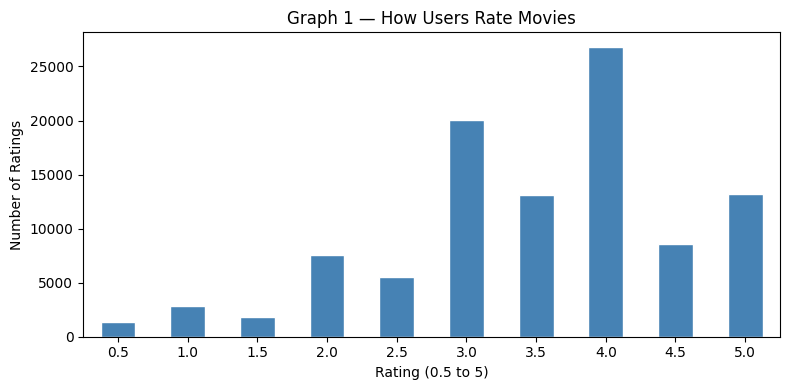

Average rating: 3.50
Most common rating: 4.0


In [ ]:
# Graph 1: Rating Distribution
plt.figure(figsize=(8, 4))
data['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Graph 1 — How Users Rate Movies')
plt.xlabel('Rating (0.5 to 5)')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Average rating: {data["rating"].mean():.2f}')
print(f'Most common rating: {data["rating"].mode()[0]}')

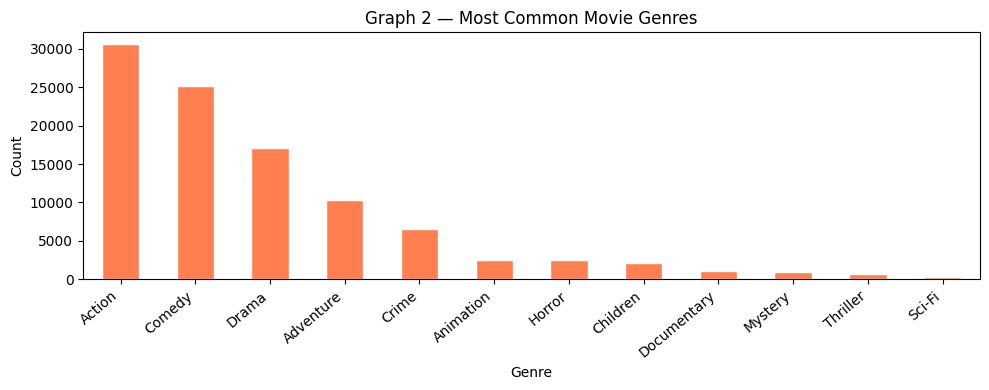

In [ ]:
# Graph 2: Most Common Genres
plt.figure(figsize=(10, 4))
data['primary_genre'].value_counts().head(12).plot(kind='bar', color='coral', edgecolor='white')
plt.title('Graph 2 — Most Common Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

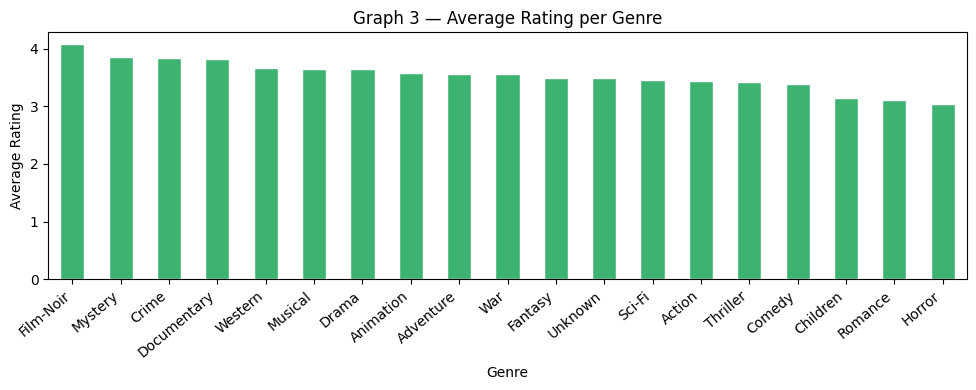

In [ ]:
# Graph 3: Average Rating per Genre
avg_by_genre = data.groupby('primary_genre')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
avg_by_genre.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Graph 3 — Average Rating per Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

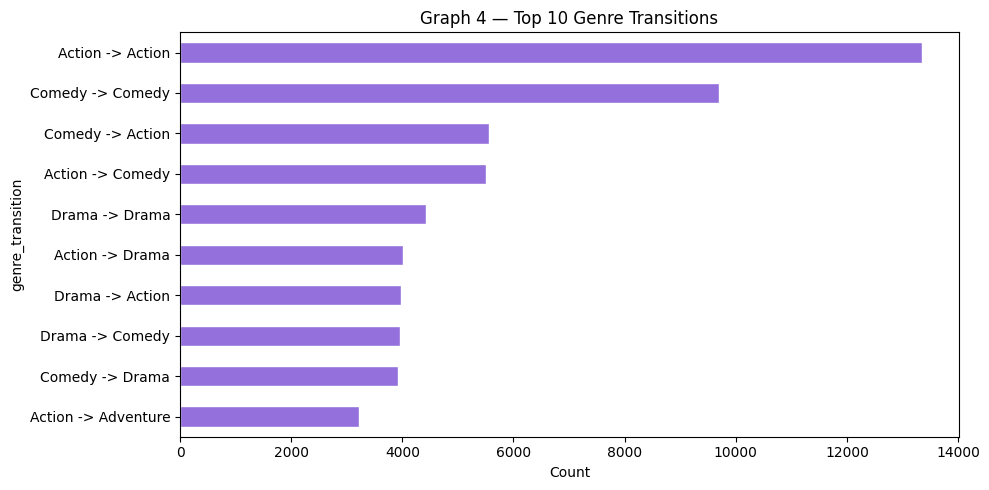

This shows which genre users tend to watch after another.


In [ ]:
# Graph 4: Top 10 Most Common Genre Transitions
real_transitions = data[data['prev_genre'] != 'None']['genre_transition']
top_transitions  = real_transitions.value_counts().head(10)

plt.figure(figsize=(10, 5))
top_transitions[::-1].plot(kind='barh', color='mediumpurple', edgecolor='white')
plt.title('Graph 4 — Top 10 Genre Transitions')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

print('This shows which genre users tend to watch after another.')

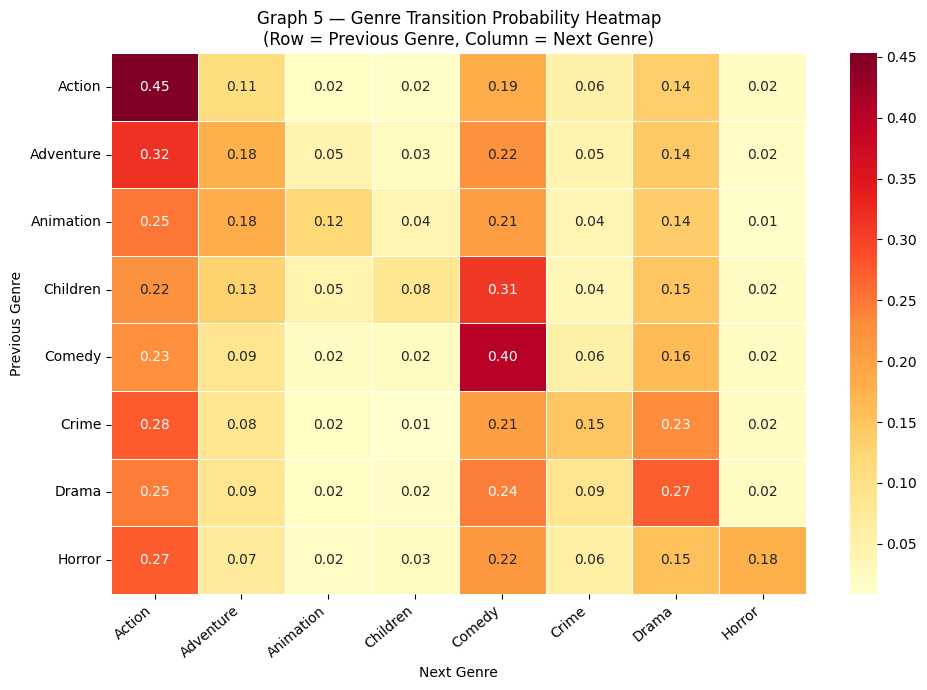

Darker colour = higher probability of that transition happening.


In [ ]:
# Graph 5: Genre Transition Heatmap
top_genres = data['primary_genre'].value_counts().head(8).index.tolist()

heat_data = data[
    data['primary_genre'].isin(top_genres) & data['prev_genre'].isin(top_genres)
]

matrix = heat_data.groupby(['prev_genre', 'primary_genre']).size().unstack(fill_value=0)
matrix = matrix.div(matrix.sum(axis=1), axis=0)  # convert to probability

plt.figure(figsize=(10, 7))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Graph 5 — Genre Transition Probability Heatmap\n(Row = Previous Genre, Column = Next Genre)')
plt.xlabel('Next Genre')
plt.ylabel('Previous Genre')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print('Darker colour = higher probability of that transition happening.')